# 03 — Profit Prediction Modeling

## Modeling Objective

The objective of this notebook is to develop a machine learning regression
model that predicts transaction-level profit using business attributes
available for the transaction.

The modeling workflow will include:

1. Define the prediction target
2. Select appropriate features
3. Identify and prevent data leakage
4. Split the data into training and testing sets
5. Preprocess numerical and categorical features
6. Train and compare regression models
7. Evaluate model performance
8. Interpret the model results

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Dataset- Superstore (2015-2018).csv")

print("Shape:", df.shape)
print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Shape: (9994, 21)

Columns:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. Country
10. City
11. State
12. Postal Code
13. Region
14. Product ID
15. Category
16. Sub-Category
17. Product Name
18. Sales
19. Quantity
20. Discount
21. Profit


In [3]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Create time-based features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order DayOfWeek"] = df["Order Date"].dt.dayofweek

# Check the new features
df[
    [
        "Order Date",
        "Order Year",
        "Order Month",
        "Order Quarter",
        "Order DayOfWeek"
    ]
].head()

,Order Date,Order Year,Order Month,Order Quarter,Order DayOfWeek
0,2016-11-08,2016,11,4,1
1,2016-11-08,2016,11,4,1
2,2016-06-12,2016,6,2,6
3,2015-10-11,2015,10,4,6
4,2015-10-11,2015,10,4,6


In [4]:
# Define target
y = df["Profit"]

# Define input features
feature_columns = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category",
    "Sales",
    "Quantity",
    "Discount",
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Order DayOfWeek"
]

X = df[feature_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (9994, 12)
y shape: (9994,)

Features:
['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [5]:
# Inspect feature data types
print(X.dtypes)

print("\nCategorical features:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical features:")
print(X.select_dtypes(exclude="object").columns.tolist())

Ship Mode              str
Segment                str
Region                 str
Category               str
Sub-Category           str
Sales              float64
Quantity             int64
Discount           float64
Order Year           int32
Order Month          int32
Order Quarter        int32
Order DayOfWeek      int32
dtype: object

Categorical features:
['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

Numerical features:
['Sales', 'Quantity', 'Discount', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


C:\Users\anasg\AppData\Local\Temp\ipykernel_16208\2549469373.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X.select_dtypes(include="object").columns.tolist())


In [6]:
# Check the number of transactions available in each year
print(df["Order Year"].value_counts().sort_index())

Order Year
2014    1993
2015    2102
2016    2587
2017    3312
Name: count, dtype: int64


In [7]:
# Time-based train/test split
train_mask = df["Order Year"] < 2017
test_mask = df["Order Year"] == 2017

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining years:", sorted(df.loc[train_mask, "Order Year"].unique()))
print("Testing years:", sorted(df.loc[test_mask, "Order Year"].unique()))

Training set:
X_train: (6682, 12)
y_train: (6682,)

Test set:
X_test: (3312, 12)
y_test: (3312,)

Training years: [np.int32(2014), np.int32(2015), np.int32(2016)]
Testing years: [np.int32(2017)]


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify feature types
categorical_features = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

numerical_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Order DayOfWeek"
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

Numerical features: ['Sales', 'Quantity', 'Discount', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek']


In [9]:
# Build preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [10]:
# Fit preprocessing using training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Training data shape after preprocessing:", X_train_processed.shape)
print("Test data shape after preprocessing:", X_test_processed.shape)

Training data shape after preprocessing: (6682, 38)
Test data shape after preprocessing: (3312, 38)


In [11]:
# Inspect the generated feature names
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nProcessed features:")
for i, feature in enumerate(feature_names, start=1):
    print(f"{i}. {feature}")

Number of processed features: 38

Processed features:
1. categorical__Ship Mode_First Class
2. categorical__Ship Mode_Same Day
3. categorical__Ship Mode_Second Class
4. categorical__Ship Mode_Standard Class
5. categorical__Segment_Consumer
6. categorical__Segment_Corporate
7. categorical__Segment_Home Office
8. categorical__Region_Central
9. categorical__Region_East
10. categorical__Region_South
11. categorical__Region_West
12. categorical__Category_Furniture
13. categorical__Category_Office Supplies
14. categorical__Category_Technology
15. categorical__Sub-Category_Accessories
16. categorical__Sub-Category_Appliances
17. categorical__Sub-Category_Art
18. categorical__Sub-Category_Binders
19. categorical__Sub-Category_Bookcases
20. categorical__Sub-Category_Chairs
21. categorical__Sub-Category_Copiers
22. categorical__Sub-Category_Envelopes
23. categorical__Sub-Category_Fasteners
24. categorical__Sub-Category_Furnishings
25. categorical__Sub-Category_Labels
26. categorical__Sub-Categor

In [12]:
from sklearn.linear_model import LinearRegression

# Create baseline regression model
linear_model = LinearRegression()

# Train the model on the preprocessed training data
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [13]:
# Generate predictions on unseen test data
y_pred_linear = linear_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_linear))

print("\nFirst 10 predictions:")
print(y_pred_linear[:10])

Number of predictions: 3312

First 10 predictions:
[-19.85370985 -77.71470381   2.60564302  26.36015281 -27.78116422
  54.97981901 -88.84836868 -97.81422773 -19.60713199   8.41563802]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE : ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²  : {r2:.4f}")

Linear Regression Performance
-----------------------------------
MAE : $58.79
RMSE: $189.96
R²  : 0.3830


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")

Random Forest model created successfully.


In [16]:
# Train Random Forest on the preprocessed training data
rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


In [17]:
# Generate predictions on the test set
y_pred_rf = rf_model.predict(X_test_processed)

print("Number of predictions:", len(y_pred_rf))

print("\nFirst 10 predictions:")
print(y_pred_rf[:10])

Number of predictions: 3312

First 10 predictions:
[  5.492477   -13.45467833   9.82610167  17.28849733 -15.21010133
   9.150058    -2.063215    -5.591465     1.21448933 -11.10563333]


In [18]:
# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE : ${mae_rf:.2f}")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest Performance
-----------------------------------
MAE : $18.16
RMSE: $98.97
R²  : 0.8325


In [19]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_rf
    ],
    "R2": [
        r2,
        r2_rf
    ]
})

print(results.to_string(index=False))

            Model       MAE       RMSE       R2
Linear Regression 58.790652 189.956572 0.382984
    Random Forest 18.159829  98.973694 0.832495


In [20]:
# Extract Random Forest feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 features:")
print(feature_importance.head(15).to_string(index=False))

Top 15 features:
                              Feature  Importance
                     numerical__Sales    0.609527
                  numerical__Discount    0.203069
          categorical__Region_Central    0.024204
                  numerical__Quantity    0.017417
    categorical__Sub-Category_Binders    0.015712
           numerical__Order DayOfWeek    0.013588
    categorical__Sub-Category_Copiers    0.013017
                numerical__Order Year    0.012901
               numerical__Order Month    0.011003
   categorical__Sub-Category_Machines    0.009429
   categorical__Sub-Category_Supplies    0.008876
             numerical__Order Quarter    0.008391
     categorical__Category_Technology    0.006311
     categorical__Segment_Home Office    0.006116
categorical__Category_Office Supplies    0.004347


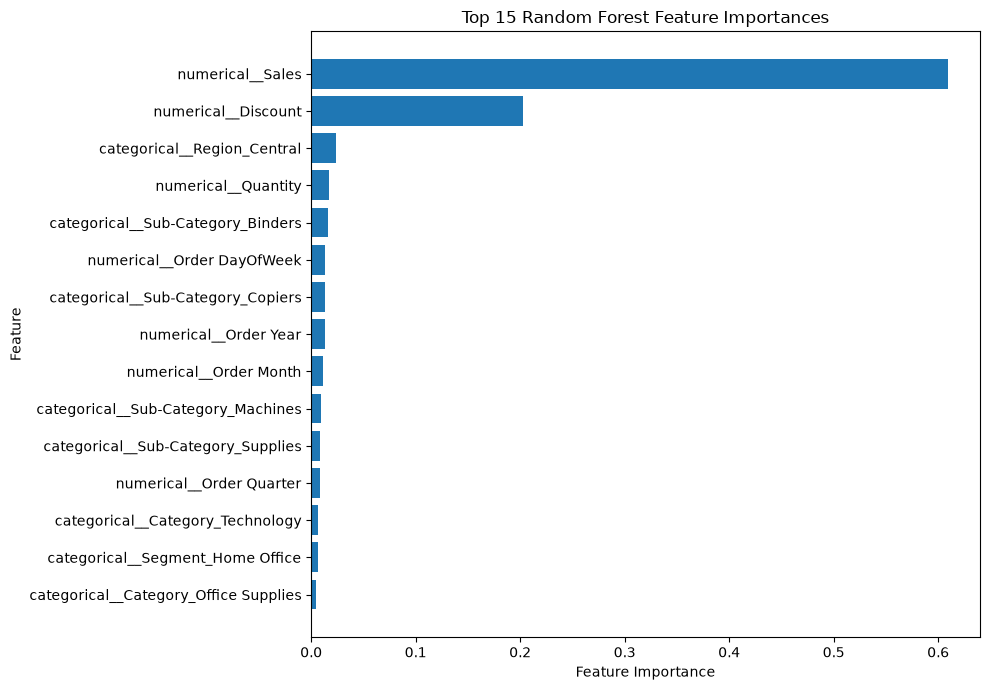

In [21]:
import matplotlib.pyplot as plt

# Select top 15 features
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [22]:
# Create a prediction error analysis table
error_analysis = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred_rf
})

error_analysis["Error"] = (
    error_analysis["Actual Profit"] -
    error_analysis["Predicted Profit"]
)

error_analysis["Absolute Error"] = (
    error_analysis["Error"].abs()
)

print("Error Analysis Summary")
print("-" * 35)
print(error_analysis["Absolute Error"].describe())

print("\nLargest prediction errors:")
print(
    error_analysis
    .sort_values("Absolute Error", ascending=False)
    .head(10)
    .to_string(index=False)
)

Error Analysis Summary
-----------------------------------
count    3312.000000
mean       18.159829
std        97.308128
min         0.000062
25%         0.364621
50%         1.811350
75%        11.914982
max      3794.177269
Name: Absolute Error, dtype: float64

Largest prediction errors:
 Actual Profit  Predicted Profit        Error  Absolute Error
    -3839.9904        -45.813131 -3794.177269     3794.177269
     6719.9808       4605.253908  2114.726892     2114.726892
    -1049.3406        780.004640 -1829.345240     1829.345240
    -3399.9800      -2190.579739 -1209.400261     1209.400261
      359.9988       1355.506106  -995.507306      995.507306
     1351.9896       2156.393351  -804.403751      804.403751
    -2287.7820      -1557.652260  -730.129740      730.129740
     5039.9856       4344.860795   695.124805      695.124805
     -386.3916      -1013.777983   627.386383      627.386383
     -377.9892       -972.107230   594.118030      594.118030


In [23]:
# Add the original row index to the error analysis
error_analysis["Row Index"] = y_test.index

# Show the 10 transactions with the largest prediction errors
worst_errors = (
    error_analysis
    .sort_values("Absolute Error", ascending=False)
    .head(10)
)

# Retrieve the original transaction details
worst_transactions = df.loc[
    worst_errors["Row Index"],
    [
        "Row ID",
        "Order ID",
        "Order Date",
        "Ship Mode",
        "Segment",
        "Region",
        "Category",
        "Sub-Category",
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]
].copy()

# Add prediction and error information
worst_transactions["Predicted Profit"] = worst_errors.set_index(
    "Row Index"
)["Predicted Profit"]

worst_transactions["Absolute Error"] = worst_errors.set_index(
    "Row Index"
)["Absolute Error"]

print(worst_transactions.to_string(index=False))

 Row ID       Order ID Order Date      Ship Mode     Segment  Region        Category Sub-Category     Sales  Quantity  Discount     Profit  Predicted Profit  Absolute Error
    684 US-2017-168116 2017-11-04       Same Day   Corporate   South      Technology     Machines  7999.980         4       0.5 -3839.9904        -45.813131     3794.177269
   8154 CA-2017-140151 2017-03-23    First Class    Consumer    West      Technology      Copiers 13999.960         4       0.0  6719.9808       4605.253908     2114.726892
   1804 CA-2017-158379 2017-09-22   Second Class    Consumer    East Office Supplies     Supplies  4663.736         7       0.2 -1049.3406        780.004640     1829.345240
   3012 CA-2017-134845 2017-04-17 Standard Class Home Office    West      Technology     Machines  2549.985         5       0.7 -3399.9800      -2190.579739     1209.400261
   4219 CA-2017-149881 2017-04-01    First Class   Corporate    West      Technology     Machines  4799.984         2       0.2   359.9

In [24]:
# Combine test-set features with prediction errors
error_analysis_with_features = X_test.copy()

error_analysis_with_features["Actual Profit"] = y_test
error_analysis_with_features["Predicted Profit"] = y_pred_rf
error_analysis_with_features["Absolute Error"] = (
    y_test - y_pred_rf
).abs()

# Group prediction error by discount level
discount_error = (
    error_analysis_with_features
    .groupby("Discount")["Absolute Error"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

print("Prediction error by discount level:")
print(discount_error.to_string(index=False))

Prediction error by discount level:
 Discount  count       mean    median         max
     0.00   1590  15.197935  1.532823 2114.726892
     0.10     28  32.185971 16.438092  203.664799
     0.15     16  28.617975 16.641858   90.658753
     0.20   1223  14.173866  1.733727 1829.345240
     0.30     68  33.289858 25.111258  361.659138
     0.32     11  31.101081 11.814046  181.216151
     0.40     69  61.263823 14.856837  627.386383
     0.45      4  66.555854 64.261188  117.176085
     0.50     19 239.081037 25.643260 3794.177269
     0.60     39   9.485172  2.632408   97.421969
     0.70    138  23.968564  0.408211 1209.400261
     0.80    107  18.388150  1.440524  730.129740


In [25]:
# Create Sales ranges for error analysis
error_analysis_with_features["Sales Range"] = pd.cut(
    error_analysis_with_features["Sales"],
    bins=[0, 100, 500, 1000, 2500, 5000, 10000, float("inf")],
    labels=[
        "0-100",
        "100-500",
        "500-1K",
        "1K-2.5K",
        "2.5K-5K",
        "5K-10K",
        "10K+"
    ]
)

# Calculate prediction error by Sales range
sales_error = (
    error_analysis_with_features
    .groupby("Sales Range", observed=True)["Absolute Error"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

print("Prediction error by Sales range:")
print(sales_error.to_string(index=False))

Prediction error by Sales range:
Sales Range  count        mean     median         max
      0-100   2085    2.161058   0.590527   40.861776
    100-500    870   18.057546  11.872353  213.460993
     500-1K    210   47.458248  31.686215  216.182529
    1K-2.5K    118  116.922808  82.379039  730.129740
    2.5K-5K     22  364.286522 194.365645 1829.345240
     5K-10K      4 1227.827092 543.858169 3794.177269
       10K+      3 1080.249651 695.124805 2114.726892


In [26]:
# Create a validation split inside the historical training period

train_mask_final = df["Order Year"] < 2016
validation_mask = df["Order Year"] == 2016

X_train_final = X.loc[train_mask_final]
X_validation = X.loc[validation_mask]

y_train_final = y.loc[train_mask_final]
y_validation = y.loc[validation_mask]

print("Final training set:")
print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("\nValidation set:")
print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("\nTraining years:", sorted(
    df.loc[train_mask_final, "Order Year"].unique()
))

print("Validation year:", sorted(
    df.loc[validation_mask, "Order Year"].unique()
))

print("Final test year: 2017")

Final training set:
X_train_final: (4095, 12)
y_train_final: (4095,)

Validation set:
X_validation: (2587, 12)
y_validation: (2587,)

Training years: [np.int32(2014), np.int32(2015)]
Validation year: [np.int32(2016)]
Final test year: 2017


In [27]:
# Create a fresh preprocessor for the validation experiment
validation_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Fit ONLY on the final training period: 2014–2015
X_train_final_processed = validation_preprocessor.fit_transform(
    X_train_final
)

# Transform validation data: 2016
X_validation_processed = validation_preprocessor.transform(
    X_validation
)

# Transform final test data: 2017
X_test_final_processed = validation_preprocessor.transform(
    X_test
)

print("Training:", X_train_final_processed.shape)
print("Validation:", X_validation_processed.shape)
print("Final test:", X_test_final_processed.shape)

Training: (4095, 38)
Validation: (2587, 38)
Final test: (3312, 38)


In [28]:
# Train Random Forest using only 2014–2015 data
rf_validation = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_validation.fit(
    X_train_final_processed,
    y_train_final
)

print("Validation Random Forest trained successfully.")

Validation Random Forest trained successfully.


In [29]:
# Generate predictions for the 2016 validation set
y_pred_validation = rf_validation.predict(
    X_validation_processed
)

print("Number of validation predictions:", len(y_pred_validation))

print("\nFirst 10 validation predictions:")
print(y_pred_validation[:10])

Number of validation predictions: 2587

First 10 validation predictions:
[  65.376023    154.27256567    6.86167333  118.77954433    5.823622
   18.92482267    4.13716      23.41664367  122.91878167 -203.008642  ]


In [30]:
# Evaluate Random Forest on the 2016 validation set
mae_validation = mean_absolute_error(
    y_validation,
    y_pred_validation
)

rmse_validation = np.sqrt(
    mean_squared_error(
        y_validation,
        y_pred_validation
    )
)

r2_validation = r2_score(
    y_validation,
    y_pred_validation
)

print("Random Forest Validation Performance")
print("-" * 40)
print(f"MAE : ${mae_validation:.2f}")
print(f"RMSE: ${rmse_validation:.2f}")
print(f"R²  : {r2_validation:.4f}")

Random Forest Validation Performance
----------------------------------------
MAE : $24.62
RMSE: $178.01
R²  : 0.5979


In [31]:
# Train Linear Regression on 2014–2015
linear_validation = LinearRegression()

linear_validation.fit(
    X_train_final_processed,
    y_train_final
)

print("Validation Linear Regression trained successfully.")

Validation Linear Regression trained successfully.


In [32]:
# Generate Linear Regression predictions on the 2016 validation set
y_pred_linear_validation = linear_validation.predict(
    X_validation_processed
)

print("Number of validation predictions:", len(y_pred_linear_validation))

print("\nFirst 10 validation predictions:")
print(y_pred_linear_validation[:10])

Number of validation predictions: 2587

First 10 validation predictions:
[ -1.45118254 107.40997165  28.45670698 103.24343871  58.15918212
  91.1957045   38.99256705  43.23957554 140.80935724 -83.07072865]


In [33]:
# Evaluate Linear Regression on the 2016 validation set
mae_linear_validation = mean_absolute_error(
    y_validation,
    y_pred_linear_validation
)

rmse_linear_validation = np.sqrt(
    mean_squared_error(
        y_validation,
        y_pred_linear_validation
    )
)

r2_linear_validation = r2_score(
    y_validation,
    y_pred_linear_validation
)

print("Linear Regression Validation Performance")
print("-" * 40)
print(f"MAE : ${mae_linear_validation:.2f}")
print(f"RMSE: ${rmse_linear_validation:.2f}")
print(f"R²  : {r2_linear_validation:.4f}")

Linear Regression Validation Performance
----------------------------------------
MAE : $62.37
RMSE: $235.10
R²  : 0.2987


In [34]:
# Compare validation performance
validation_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear_validation,
        mae_validation
    ],
    "RMSE": [
        rmse_linear_validation,
        rmse_validation
    ],
    "R2": [
        r2_linear_validation,
        r2_validation
    ]
})

validation_results

,Model,MAE,RMSE,R2
0,Linear Regression,62.374849,235.097216,0.298661
1,Random Forest,24.618009,178.007758,0.597921


In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_configs = {
    "RF_200": {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    "RF_300": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    "RF_300_leaf2": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2
    },
    "RF_300_leaf4": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 4
    }
}

tuning_results = []

for name, params in rf_configs.items():

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_final_processed,
        y_train_final
    )

    predictions = model.predict(
        X_validation_processed
    )

    tuning_results.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_validation,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_validation,
                predictions
            )
        ),
        "R2": r2_score(
            y_validation,
            predictions
        )
    })

tuning_results = pd.DataFrame(tuning_results)

tuning_results

,Model,MAE,RMSE,R2
0,RF_200,24.584451,175.589679,0.608771
1,RF_300,24.618009,178.007758,0.597921
2,RF_300_leaf2,25.815601,192.729840,0.528663
3,RF_300_leaf4,27.165892,202.284746,0.480770


In [36]:
# Prepare the final training dataset using 2014–2016
final_train_mask = df["Order Year"] < 2017

X_train_final_full = X.loc[final_train_mask]
y_train_final_full = y.loc[final_train_mask]

# Fit preprocessing only on the final training data
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

X_train_final_processed_full = final_preprocessor.fit_transform(
    X_train_final_full
)

# Transform the untouched 2017 test data
X_test_final_processed = final_preprocessor.transform(
    X_test
)

print("Final training shape:", X_train_final_processed_full.shape)
print("Final test shape:", X_test_final_processed.shape)
print("Final training years:", sorted(X_train_final_full["Order Year"].unique()))
print("Final test years:", sorted(X_test["Order Year"].unique()))

Final training shape: (6682, 38)
Final test shape: (3312, 38)
Final training years: [np.int32(2014), np.int32(2015), np.int32(2016)]
Final test years: [np.int32(2017)]


In [37]:
# Train the final Random Forest model on 2014–2016

final_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_train_final_processed_full,
    y_train_final_full
)

print("Final Random Forest trained successfully.")

Final Random Forest trained successfully.


In [38]:
# Generate predictions on the untouched 2017 test set

y_pred_final = final_rf.predict(
    X_test_final_processed
)

print("Number of final test predictions:", len(y_pred_final))

print("\nFirst 10 final test predictions:")
print(y_pred_final[:10])

Number of final test predictions: 3312

First 10 final test predictions:
[  5.5040585 -13.417226    9.8438215  18.7204815 -15.4079705   9.1420665
  -2.0696485  -5.5050755   1.255254   -8.4329105]


In [39]:
# Evaluate the final Random Forest on the untouched 2017 test set

mae_final = mean_absolute_error(
    y_test,
    y_pred_final
)

rmse_final = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_final
    )
)

r2_final = r2_score(
    y_test,
    y_pred_final
)

print("Final Random Forest Test Performance")
print("-" * 45)
print(f"MAE : ${mae_final:.2f}")
print(f"RMSE: ${rmse_final:.2f}")
print(f"R²  : {r2_final:.4f}")

Final Random Forest Test Performance
---------------------------------------------
MAE : $18.13
RMSE: $97.48
R²  : 0.8375


In [40]:
# Extract feature importance from the final Random Forest

final_feature_names = final_preprocessor.get_feature_names_out()

final_importance = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": final_rf.feature_importances_
})

final_importance = final_importance.sort_values(
    by="Importance",
    ascending=False
)

final_importance.head(15)

,Feature,Importance
31,numerical__Sales,0.606351
33,numerical__Discount,0.204621
7,categorical__Region_Central,0.024048
32,numerical__Quantity,0.017294
17,categorical__Sub-Category_Binders,0.015523
20,categorical__Sub-Category_Copiers,0.014209
34,numerical__Order Year,0.013999
37,numerical__Order DayOfWeek,0.013679
35,numerical__Order Month,0.012195
25,categorical__Sub-Category_Machines,0.009861


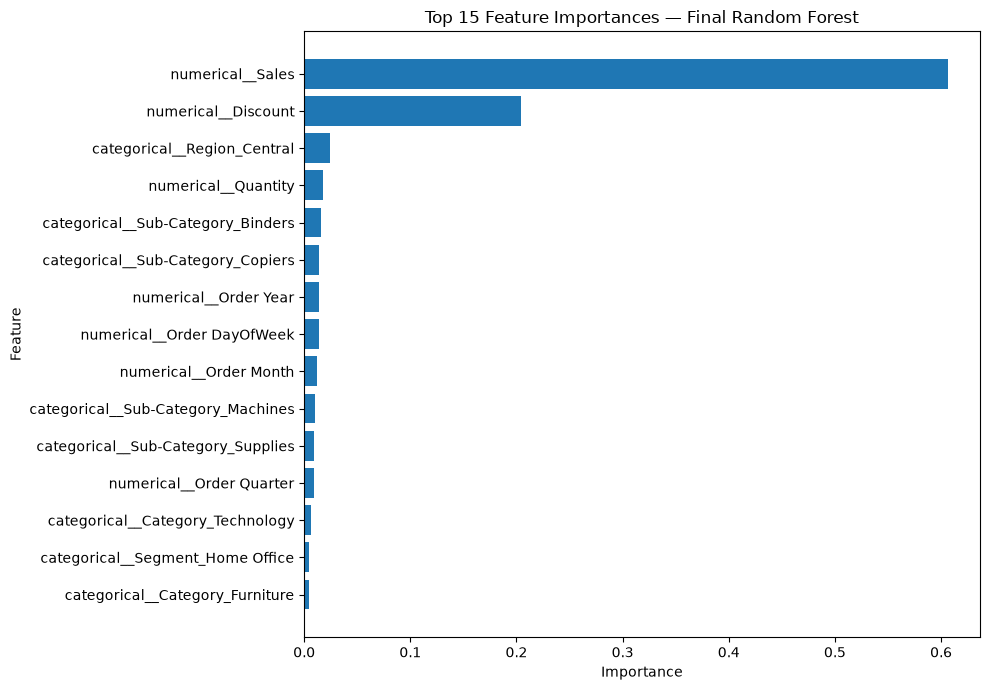

In [41]:
import matplotlib.pyplot as plt

top_features = final_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Final Random Forest")

plt.tight_layout()
plt.show()

In [42]:
import joblib
import os

# Make sure the models directory exists
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(
    final_rf,
    "../models/final_random_forest.pkl"
)

# Save the fitted preprocessor
joblib.dump(
    final_preprocessor,
    "../models/final_preprocessor.pkl"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


In [43]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_rf)
    ]
)

# Test that the complete pipeline can reproduce the final predictions
pipeline_predictions = final_pipeline.predict(X_test)

print("Pipeline created successfully.")
print("Number of test predictions:", len(pipeline_predictions))

print("\nFirst 5 pipeline predictions:")
print(pipeline_predictions[:5])

Pipeline created successfully.
Number of test predictions: 3312

First 5 pipeline predictions:
[  5.5040585 -13.417226    9.8438215  18.7204815 -15.4079705]


In [44]:
# Save the complete preprocessing + model pipeline with compression

joblib.dump(
    final_pipeline,
    "../models/final_profit_prediction_pipeline.pkl",
    compress=3
)

print("Final prediction pipeline saved successfully.")

Final prediction pipeline saved successfully.


In [45]:
# Verify that the saved pipeline can be loaded

loaded_pipeline = joblib.load(
    "../models/final_profit_prediction_pipeline.pkl"
)

loaded_predictions = loaded_pipeline.predict(X_test)

print("Saved pipeline loaded successfully.")
print("Number of predictions:", len(loaded_predictions))

print("\nFirst 5 predictions:")
print(loaded_predictions[:5])

Saved pipeline loaded successfully.
Number of predictions: 3312

First 5 predictions:
[  5.5040585 -13.417226    9.8438215  18.7204815 -15.4079705]
